# context_length sweep — blaine / residue

Chronos-2 full fine-tune (predlen 4 train / 1-step eval, 1000 steps, lr 1e-6, batch 64), sweeping `context_length` over 512 / 768 / 1024 / 1280 / 1536. Each ctx is also evaluated zero-shot (no fine-tune), since context_length changes the inference input itself.

Primary metric: **normalized skill score** = per-station `model_MAE / naive_MAE`, macro-averaged across the 3 stations (2CM/3CM/4CM). `< 1` beats the naive "repeat last lab reading" baseline.

Source: `eval/backtest_{target}_ctx{N}_{zeroshot,full}.csv` written by `experiments/run_ctx_sweep.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'experiments' else Path.cwd()
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score

CONTEXT_LENGTHS = [512, 768, 1024, 1280, 1536]
TARGETS = ['blaine', 'residue']
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

In [2]:
def load_backtest(target, ctx, method):
    p = ROOT / 'eval' / f'backtest_{target}_ctx{ctx}_{method}.csv'
    if not p.exists():
        return None
    return pd.read_csv(p, parse_dates=['timestamp'])

rows = []
for target in TARGETS:
    lo, hi = cfg.SPEC_RANGES[target]
    for ctx in CONTEXT_LENGTHS:
        for method in ['zeroshot', 'full']:
            df = load_backtest(target, ctx, method)
            if df is None:
                continue
            m = compute_metrics(df, (lo, hi), pred_col='pred')
            naive = compute_metrics(df.assign(pred=df['naive_pred']), (lo, hi), pred_col='pred')
            rows.append({
                'target': target, 'ctx': ctx, 'method': method, 'n': len(df),
                'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R2': m['R2'],
                'spec_acc': m['spec_accuracy'], 'coverage80': m.get('interval_coverage', np.nan),
                'macro_MAE': macro_average_mae(df),
                'skill_score': normalized_skill_score(df),
                'naive_MAE': naive['MAE'], 'naive_R2': naive['R2'], 'naive_spec_acc': naive['spec_accuracy'],
            })

summary = pd.DataFrame(rows)
if summary.empty:
    print('no backtest CSVs found yet')
summary

,target,ctx,method,n,MAE,RMSE,R2,spec_acc,coverage80,macro_MAE,skill_score,naive_MAE,naive_R2,naive_spec_acc
0,blaine,512,zeroshot,851,72.9584,99.0395,0.4188,0.6745,0.6510,72.9880,0.8726,83.7673,0.1629,0.6698
1,blaine,512,full,851,69.6349,94.2505,0.4737,0.7015,0.6616,69.5736,0.8319,83.7673,0.1629,0.6698
2,blaine,768,zeroshot,852,74.0933,100.0219,0.4066,0.6843,0.6385,74.1525,0.8860,83.7629,0.1625,0.6702
3,blaine,768,full,852,69.2941,93.6004,0.4803,0.7077,0.6303,69.2787,0.8281,83.7629,0.1625,0.6702
4,blaine,1024,zeroshot,852,75.5057,101.3741,0.3904,0.6784,0.6197,75.5345,0.9025,83.7629,0.1625,0.6702
5,blaine,1024,full,852,69.4746,93.7405,0.4788,0.7101,0.6608,69.4569,0.8302,83.7629,0.1625,0.6702
6,blaine,1280,zeroshot,852,75.8543,101.6906,0.3866,0.6772,0.5974,75.8953,0.9070,83.7629,0.1625,0.6702
7,blaine,1280,full,852,69.5419,93.9085,0.4769,0.7136,0.6303,69.5437,0.8309,83.7629,0.1625,0.6702
8,blaine,1536,zeroshot,852,76.4006,101.8745,0.3844,0.6714,0.5904,76.4425,0.9139,83.7629,0.1625,0.6702
9,blaine,1536,full,852,68.9334,92.8805,0.4883,0.7066,0.6796,68.9180,0.8238,83.7629,0.1625,0.6702


## blaine

In [3]:
t = summary[summary['target'] == 'blaine'].copy()
if not t.empty:
    view = t.set_index(['method', 'ctx'])[
        ['n', 'MAE', 'RMSE', 'R2', 'spec_acc', 'coverage80', 'macro_MAE', 'skill_score']
    ].sort_index()
    display(view)
    nb = t.groupby('ctx')[['naive_MAE', 'naive_R2', 'naive_spec_acc']].first()
    print('naive baseline (per ctx = per eval set):')
    display(nb)
else:
    print('no rows yet')

n     MAE     RMSE     R2  spec_acc  coverage80  macro_MAE  \
method   ctx                                                                  
full     512   851 69.6349  94.2505 0.4737    0.7015      0.6616    69.5736   
         768   852 69.2941  93.6004 0.4803    0.7077      0.6303    69.2787   
         1024  852 69.4746  93.7405 0.4788    0.7101      0.6608    69.4569   
         1280  852 69.5419  93.9085 0.4769    0.7136      0.6303    69.5437   
         1536  852 68.9334  92.8805 0.4883    0.7066      0.6796    68.9180   
zeroshot 512   851 72.9584  99.0395 0.4188    0.6745      0.6510    72.9880   
         768   852 74.0933 100.0219 0.4066    0.6843      0.6385    74.1525   
         1024  852 75.5057 101.3741 0.3904    0.6784      0.6197    75.5345   
         1280  852 75.8543 101.6906 0.3866    0.6772      0.5974    75.8953   
         1536  852 76.4006 101.8745 0.3844    0.6714      0.5904    76.4425   

               skill_score  
method   ctx                
full     512        0.8319  
         768        0.8281  
         1024       0.8302  
         1280       0.8309  
         1536       0.8238  
zeroshot 512        0.8726  
         768        0.8860  
         1024       0.9025  
         1280       0.9070  
         1536       0.9139

naive baseline (per ctx = per eval set):


,naive_MAE,naive_R2,naive_spec_acc
ctx,,,
512,83.7673,0.1629,0.6698
768,83.7629,0.1625,0.6702
1024,83.7629,0.1625,0.6702
1280,83.7629,0.1625,0.6702
1536,83.7629,0.1625,0.6702


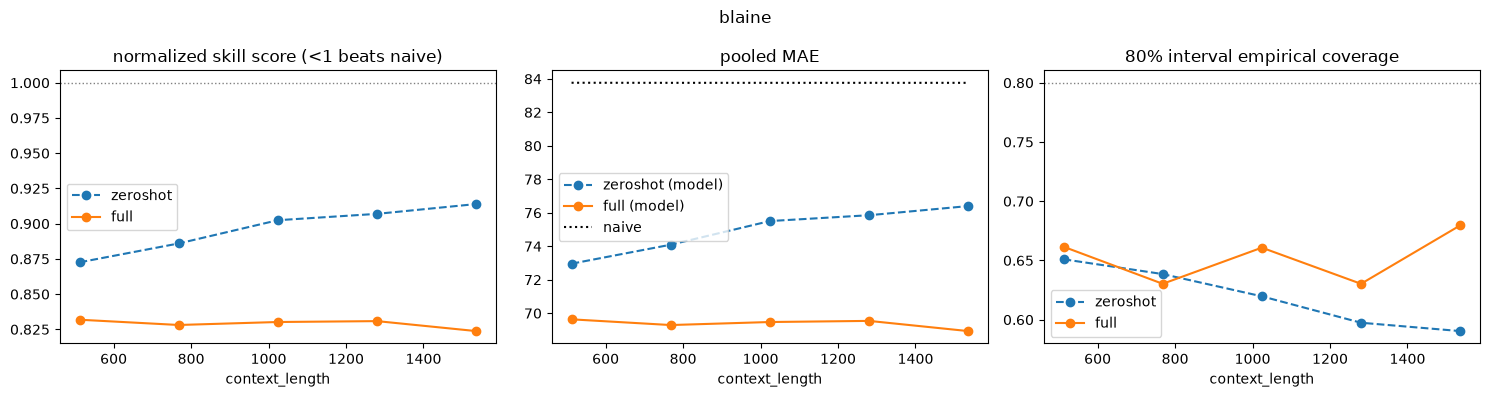

In [4]:
t = summary[summary['target'] == 'blaine'].copy()
if not t.empty:
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for method, mk in [('zeroshot', 'o--'), ('full', 'o-')]:
        s = t[t['method'] == method].sort_values('ctx')
        if s.empty:
            continue
        ax[0].plot(s['ctx'], s['skill_score'], mk, label=method)
        ax[1].plot(s['ctx'], s['MAE'], mk, label=f'{method} (model)')
        ax[2].plot(s['ctx'], s['coverage80'], mk, label=method)
    ax[0].axhline(1.0, color='grey', lw=1, ls=':')
    ax[0].set_title('normalized skill score (<1 beats naive)'); ax[0].set_xlabel('context_length'); ax[0].legend()
    nmae = t.groupby('ctx')['naive_MAE'].first().sort_index()
    ax[1].plot(nmae.index, nmae.values, 'k:', label='naive')
    ax[1].set_title('pooled MAE'); ax[1].set_xlabel('context_length'); ax[1].legend()
    ax[2].axhline(0.8, color='grey', lw=1, ls=':')
    ax[2].set_title('80% interval empirical coverage'); ax[2].set_xlabel('context_length'); ax[2].legend()
    fig.suptitle('blaine')
    plt.tight_layout(); plt.show()

## residue

In [5]:
t = summary[summary['target'] == 'residue'].copy()
if not t.empty:
    view = t.set_index(['method', 'ctx'])[
        ['n', 'MAE', 'RMSE', 'R2', 'spec_acc', 'coverage80', 'macro_MAE', 'skill_score']
    ].sort_index()
    display(view)
    nb = t.groupby('ctx')[['naive_MAE', 'naive_R2', 'naive_spec_acc']].first()
    print('naive baseline (per ctx = per eval set):')
    display(nb)
else:
    print('no rows yet')

n    MAE   RMSE     R2  spec_acc  coverage80  macro_MAE  \
method   ctx                                                               
full     512   856 0.4671 0.7874 0.7607    0.8259      0.6846     0.4671   
         768   856 0.4714 0.7880 0.7603    0.8154      0.7044     0.4714   
         1024  856 0.4788 0.7932 0.7572    0.8154      0.6636     0.4786   
         1280  856 0.4807 0.7966 0.7551    0.8096      0.6717     0.4803   
         1536  856 0.4861 0.7983 0.7540    0.8178      0.6752     0.4859   
zeroshot 512   856 0.4862 0.8106 0.7464    0.8166      0.6297     0.4860   
         768   856 0.4972 0.8081 0.7480    0.8061      0.6028     0.4976   
         1024  856 0.5182 0.8269 0.7361    0.7956      0.5584     0.5183   
         1280  856 0.5350 0.8444 0.7248    0.7921      0.5245     0.5350   
         1536  856 0.5539 0.8640 0.7119    0.7827      0.4965     0.5538   

               skill_score  
method   ctx                
full     512        0.8249  
         768        0.8326  
         1024       0.8450  
         1280       0.8480  
         1536       0.8568  
zeroshot 512        0.8570  
         768        0.8786  
         1024       0.9151  
         1280       0.9438  
         1536       0.9761

naive baseline (per ctx = per eval set):


,naive_MAE,naive_R2,naive_spec_acc
ctx,,,
512,0.5685,0.5778,0.7850
768,0.5685,0.5778,0.7850
1024,0.5685,0.5778,0.7850
1280,0.5685,0.5778,0.7850
1536,0.5685,0.5778,0.7850


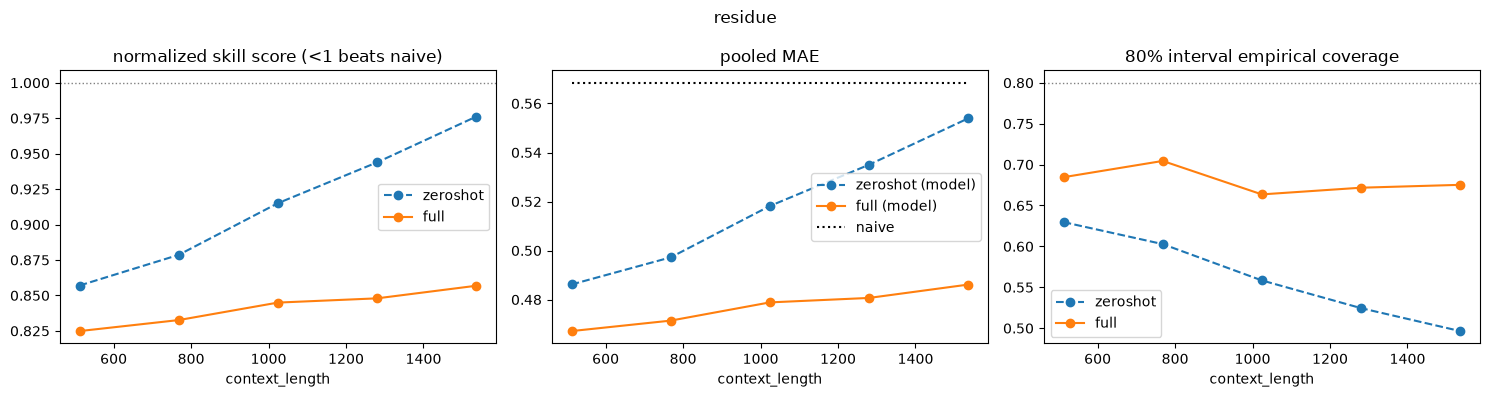

In [6]:
t = summary[summary['target'] == 'residue'].copy()
if not t.empty:
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for method, mk in [('zeroshot', 'o--'), ('full', 'o-')]:
        s = t[t['method'] == method].sort_values('ctx')
        if s.empty:
            continue
        ax[0].plot(s['ctx'], s['skill_score'], mk, label=method)
        ax[1].plot(s['ctx'], s['MAE'], mk, label=f'{method} (model)')
        ax[2].plot(s['ctx'], s['coverage80'], mk, label=method)
    ax[0].axhline(1.0, color='grey', lw=1, ls=':')
    ax[0].set_title('normalized skill score (<1 beats naive)'); ax[0].set_xlabel('context_length'); ax[0].legend()
    nmae = t.groupby('ctx')['naive_MAE'].first().sort_index()
    ax[1].plot(nmae.index, nmae.values, 'k:', label='naive')
    ax[1].set_title('pooled MAE'); ax[1].set_xlabel('context_length'); ax[1].legend()
    ax[2].axhline(0.8, color='grey', lw=1, ls=':')
    ax[2].set_title('80% interval empirical coverage'); ax[2].set_xlabel('context_length'); ax[2].legend()
    fig.suptitle('residue')
    plt.tight_layout(); plt.show()

## Best context_length per target

In [7]:
if not summary.empty:
    full = summary[summary['method'] == 'full']
    best = full.loc[full.groupby('target')['skill_score'].idxmin()]
    display(best[['target', 'ctx', 'MAE', 'R2', 'spec_acc', 'coverage80', 'skill_score']])
    for _, r in best.iterrows():
        verdict = 'beats' if r['skill_score'] < 1 else 'loses to'
        print(f"{r['target']}: best ctx = {int(r['ctx'])}  "
              f"(skill {r['skill_score']:.4f}, {verdict} naive; MAE {r['MAE']:.3f}, R2 {r['R2']:.4f})")

,target,ctx,MAE,R2,spec_acc,coverage80,skill_score
9,blaine,1536,68.9334,0.4883,0.7066,0.6796,0.8238
11,residue,512,0.4671,0.7607,0.8259,0.6846,0.8249


blaine: best ctx = 1536  (skill 0.8238, beats naive; MAE 68.933, R2 0.4883)
residue: best ctx = 512  (skill 0.8249, beats naive; MAE 0.467, R2 0.7607)


## Conclusion (2026-09-06)

**`context_length = 512` for both targets.**

- **blaine** is essentially flat across 512-1536 (full-finetune skill 0.824-0.832, all   inside retrain noise ~0.004). ctx1536 is nominally best on MAE/R2 but not meaningfully.
- **residue** gets *monotonically worse* with more context (full-finetune skill   0.825 -> 0.857 as ctx 512 -> 1536). ctx512 is the clear best.
- **zero-shot** degrades monotonically with context for both targets   (blaine 0.873 -> 0.914, residue 0.857 -> 0.976) -- longer history adds noise, not signal,   on this measured-actual dataset.
- Every full-finetune combo beats the naive baseline (skill < 1); blaine ~0.83, residue ~0.83-0.86.
- 80% interval coverage stays 49-68% (target 80%) at every ctx -- unchanged open issue.

This **contradicts the old pipeline's finding** (blaine 1024 / residue 1536 best), which was measured on the pre-cleanup xlsx that had non-measurement-hour values bleeding in. On the measured-actual data, short context wins.

ctx512 also trains fastest by far (~2.6 min vs ~92 min at ctx1536 on this 8GB GPU).

Follow-up worth a look: sweep *below* 512 (256/384) -- the whole >=512 range is flat-to-worse, so the optimum may be shorter still.

_Per-run timings: `experiments/ctx_sweep.log`. Write-up: `EXPERIMENT_LOG.md`._